In [1]:
!pip install shap


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


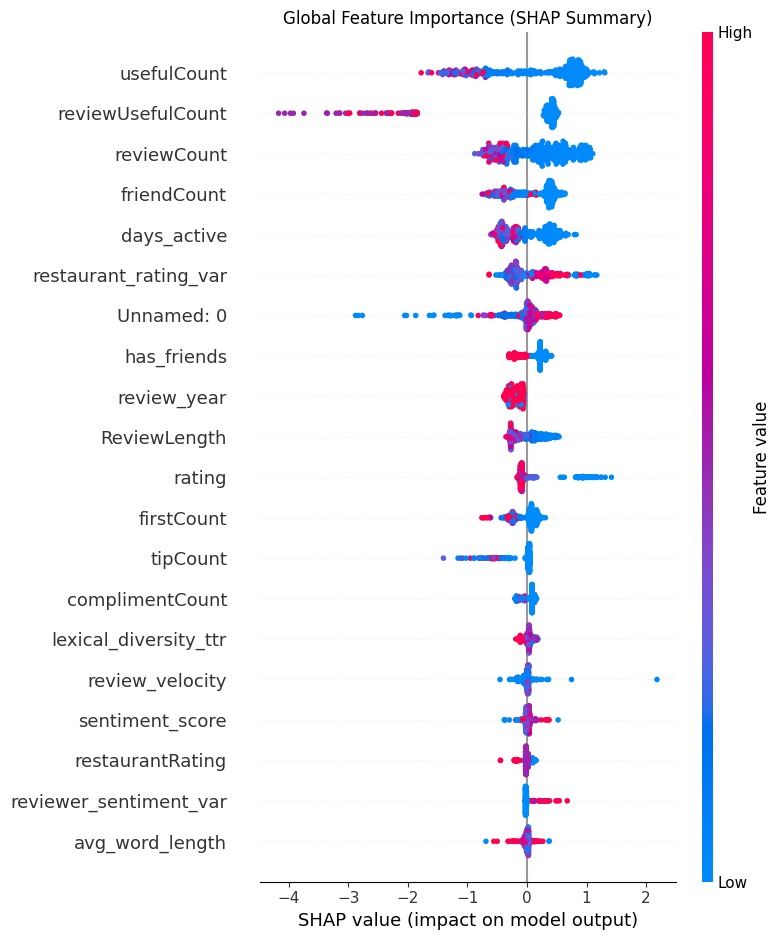

Explaining review prediction index 0:


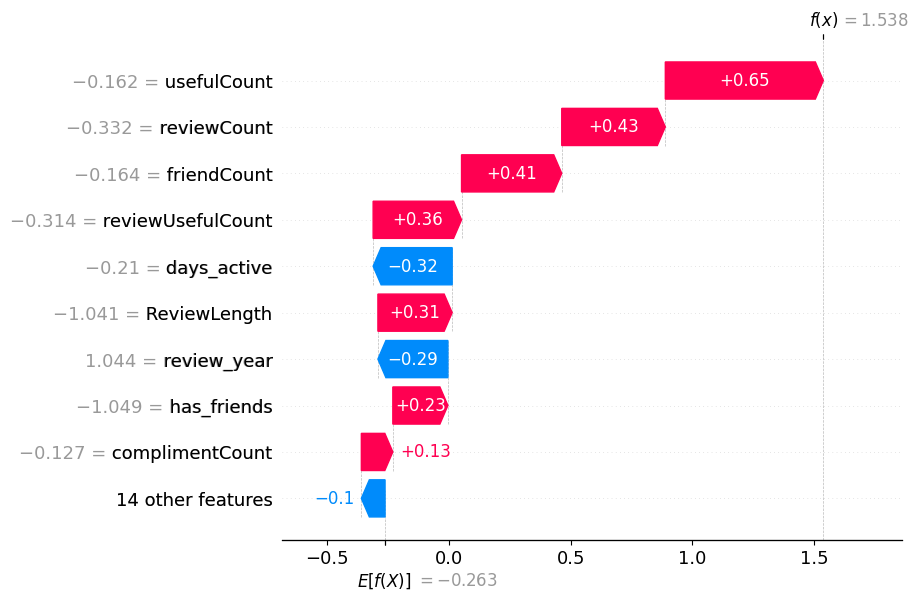

<Figure size 640x480 with 0 Axes>

In [5]:
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# load model and data
model = joblib.load('../models/final_gradient_boost_model.pkl')
X_test = pd.read_csv('../data/X_test_scaled.csv')

# initialize tree explainer for gradient boosting
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# global explanation summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Global Feature Importance (SHAP Summary)")
plt.tight_layout()
plt.savefig("../images-recordings/figures/shap_feature_importance.png")
plt.show()

# local explanation for the very first review in test set
print("Explaining review prediction index 0:")
shap.plots.waterfall(shap_values[0])
plt.savefig("../images-recordings/figures/shap_importance_scores.png")